#1.2 Data Loading

1. Digunakan GPU pada proses ini untuk mempercepat proses training.

2. Mnist merupakan dataset handwritten digits dengan size 28x28, sehingga besar data input adalah 28x28.
3. Output Cross Entropy adalah 0 dan 1 atau confidence dari data adalah suatu kelas tertentu. Untuk agar proses training berjalan lebih cepat dilakukan normalisasi data terlebih dahulu.

4. dilakukan pembagian training, validation, dan testing set dengan ukuran seperti dibawah.
- Ukuran training set : X = 50000 x 784, Y = 50000
- Ukuran validation set : X = 10000 x 784, Y = 10000
- Ukuran testing set : X = 10000 x 784, Y = 10000



In [ ]:
# Memuat semua library yang dibutuhkan untuk proses training dan testing model
# pada MNIST Handwritten Digits Dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
# Pengaturan untuk menentukan device komputasi yang akan digunakan
device = "gpu"
print(f"Using device: {device}")

# Proses pengambilan (fetch) MNIST dataset (dengan fipe 784-pixel vectors)
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"].astype(np.int8)

# Normalize the input data to the range [0, 1] so it doesn't get mode collapsed
X = X / 255.0

# Pembagian dataset ke dalam training, validation, testing sets
X_train_val, X_test = X[:60000], X[60000:]
y_train_val, y_test = y[:60000], y[60000:]
# Persiapan tupples untuk training, validation dan testing
train_data = (X_train_val[:50000], y_train_val[:50000])
val_data = (X_train_val[50000:], y_train_val[50000:])
test_data = (X_test, y_test)


print("Ukuran training set : x={}*{} y={}*1".format(len(train_data[0]),
                                                    len(train_data[0][1]),
                                                    len(train_data[1])))
print("validation set : x={}*{} y={}*1".format(len(val_data[0]),
                                                      len(val_data[0][1]),
                                                      len(val_data[1])))

print("Ukuran testing set : x={}*{} y={}*1".format(len(test_data[0]),
                                                   len(test_data[0][1]),
                                                   len(test_data[1])))

# Catatan:
# - Dimensi ke-0 pada setiap x dan y = Banyaknya data (N)
# - Dimensi ke-1 dari x = Ukuran gambar (28x28=784)
# - Dimensi ke-1 dari y = Keberadaan label untuk setiap data)


Using device: gpu
Ukuran training set : x=50000*784 y=50000*1
validation set : x=10000*784 y=10000*1
Ukuran testing set : x=10000*784 y=10000*1


# 1.3 Data Preparation

1. Pada data preparation didefinisikan hyperparameter
2. Get batches mengambil data per batch
3. Pada masing2 data loader diambil batches
4. Dilakukan printing dataset dengan matplotlib

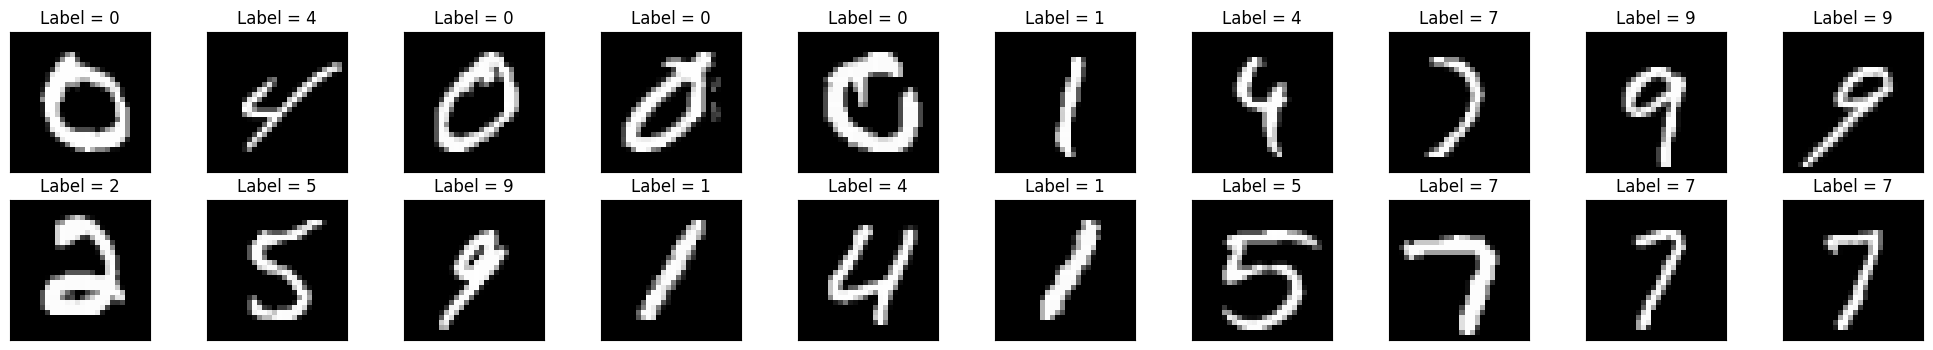

In [ ]:
# Data constants
input_size = 28 * 28
num_classes = 10
# Hyperparameters
batch_size = 64
lr = 0.1
num_epochs = 50
hidden_size = 2
selected_loss_type = 'sum_absolute' # Options: 'sum_absolute', 'mse', 'cross_entropy'

def get_batches(data, batch_size, shuffle=False):
    x, y = data
    n_samples = len(x[0])
    indices = np.arange(n_samples)
    if shuffle:
        np.random.shuffle(indices)
    for i in range(0, n_samples, batch_size):
        batch_indices = indices[i:i + batch_size]
        # keluarannya adalah x[batch_size][784] dan y[batch_size][1]
        yield x[batch_indices], y[batch_indices]
# Penggunaan (Generator)
train_loader = lambda: get_batches(train_data, batch_size, shuffle=True)
val_loader = lambda: get_batches(val_data, batch_size, shuffle=False)
test_loader = lambda: get_batches(test_data, batch_size, shuffle=False)

# Pembuatan fungsi untuk melakukan konversi images
def img_convert(input_array):
    image = input_array.copy()
    # Jika input_array berbentuk (C, H, W), ubah menjadi (H, W, C)
    if image.ndim == 3:
        image = image.transpose(1, 2, 0)
    # Merubah rentang nilai dari [-1, 1] ke [0, 1]
    image = image * 0.5 + 0.5
    # Memastikan agar nilai data citra berada pada rentang [0,1]
    image = np.clip(image, 0, 1)
    return image


# Pembuatan fungsi untuk melakukan konversi images
def img_convert(input_array):
    image = input_array.copy()
    # Jika input_array berbentuk (C, H, W), ubah menjadi (H, W, C)
    if image.ndim == 3:
        image = image.transpose(1, 2, 0)
    # Merubah rentang nilai dari [-1, 1] ke [0, 1]
    image = image * 0.5 + 0.5
    # Memastikan agar nilai data citra berada pada rentang [0,1]
    image = np.clip(image, 0, 1)
    return image

# Menampilkan data yang sudah dimuat menggunakan generator NumPy
images, labels = next(train_loader())
fig = plt.figure(figsize=(25, 4))
for idx in range(20):
    ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])
    img_to_show = images[idx].reshape(1, 28, 28)
    plt.imshow(img_convert(img_to_show), cmap='gray')
    ax.set_title("Label = " + str(labels[idx]))
plt.show()

#2.1 Utils


Merupakan daftar fungsi pembantu yang digunakan pada kalkulasi,
daftar fungsi :
1. loss_sumAbsolute : menghitung sumAbsolute loss yaitu pengurangan langsung yreal-ypred
2. loss_mse : menghitung loss MSE atau loss euclidian
3. loss_crossEntropy : menghitung loss cross entropy per class yang menghasilkan peluang tertinggi pada proses klasifikasi.
4. accuracy : menghitung akurasi dari hasil prediksi, yaitu mean dari prediksi benar pada test set.
5. sgd : yaitu fungsi untuk update w dan b dengan stochastic gradient descent per batch.
6. relu_activation : fungsi aktivasi dari hidden layer, hanya memfilter data untuk menghasilkan input positif dan menghasilkan nonlinearitas.
7. softmax_output : fungsi aktivasi untuk classifier, menghasilkan
8. forward pass : Mengisi neuron untuk mengkalkulasi loss.
9. backward_pass : Metode Gradient descent, memiliki method yang berbeda setiap fungsi loss yang digunakan.
10. init_model : inisiasi weight dan bias awal dengan randomized values.


In [ ]:
import numpy as np

# Pendefinisian fungsi untuk perhitungan loss/error (Versi NumPy)
def loss_sumAbsolute(outputs, labels, num_classes):
    one_hot_labels = np.eye(num_classes)[labels]
    loss = np.abs(outputs - one_hot_labels)
    return np.sum(loss)

# Pendefinisian fungsi untuk perhitungan loss/error (Euclidean/MSE)
def loss_mse(outputs, labels, num_classes):
    one_hot_labels = np.eye(num_classes)[labels]
    loss = (outputs - one_hot_labels)**2
    return np.sum(loss) / len(outputs) # Mean over batch, sum over classes

# Pendefinisian fungsi untuk perhitungan loss/error (Cross-Entropy)
def loss_crossEntropy(outputs, labels, num_classes):
    one_hot_labels = np.eye(num_classes)[labels]
    epsilon = 1e-15
    outputs = np.clip(outputs, epsilon, 1.0 - epsilon)
    loss = -np.mean(np.sum(one_hot_labels * np.log(outputs), axis=1))
    return loss

# Mendefinisikan function untuk menghitung akurasi dari hasil prediksi
def accuracy(outputs, labels):
    # outputs shape: [batch_size, 10]
    labels_pred = np.argmax(outputs, axis=1)
    acc = np.mean(labels_pred == labels)
    return acc

# Pendefinisian fungsi untuk proses update w dan b dengan SGD
def sgd(params, grads, lr, batch_size):
    for key in params.keys():
        params[key] -= lr * grads[key] / batch_size

# Helper function for ReLU activation
def relu_activation(x):
    return np.maximum(0, x)

# Helper function for Softmax activation
def softmax_output(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# General forward pass function for multi-layer MLP
def forward_pass(images, params, num_layers):
    layer_outputs = {'A0': images} # A0 is the input layer's activation
    A_prev = images

    for i in range(num_layers):
        W = params[f'W{i+1}']
        b = params[f'b{i+1}']
        Z = np.dot(A_prev, W) + b
        layer_outputs[f'Z{i+1}'] = Z
        if i < num_layers - 1:  # Hidden layers use ReLU
            A_prev = relu_activation(Z)
            layer_outputs[f'A{i+1}'] = A_prev
        else:  # Output layer uses Softmax
            A_prev = softmax_output(Z)
            layer_outputs[f'A{i+1}'] = A_prev # A_prev here is the final output (probabilities)
    return layer_outputs

# General backward pass function for multi-layer MLP
def backward_pass(images, labels, params, layer_outputs, num_classes, num_layers, loss_type='sum_absolute'):
    grads = {}
    y_true = np.eye(num_classes)[labels]

    # Calculate dL_dZ for the output layer based on loss type
    dL_dZ = None
    if loss_type == 'sum_absolute':
        # This is a simplification. For Softmax with L1, the derivative is complex.
        # Approximating dL/dZ as (output - target) similar to cross-entropy for softmax.
        dL_dZ = layer_outputs[f'A{num_layers}'] - y_true
    elif loss_type == 'cross_entropy':
        dL_dZ = layer_outputs[f'A{num_layers}'] - y_true
    elif loss_type == 'mse':
        dL_dA = 2 * (layer_outputs[f'A{num_layers}'] - y_true)
        S = layer_outputs[f'A{num_layers}']
        dL_dZ = S * (dL_dA - np.sum(dL_dA * S, axis=1, keepdims=True))
    else:
        raise ValueError(f"Unsupported loss type: {loss_type}")

    # Backpropagate through output layer
    grads[f'grad_W{num_layers}'] = np.dot(layer_outputs[f'A{num_layers-1}'].T, dL_dZ)
    grads[f'grad_b{num_layers}'] = np.sum(dL_dZ, axis=0)

    dL_dA_prev = np.dot(dL_dZ, params[f'W{num_layers}'].T)

    # Backpropagate through hidden layers
    for i in reversed(range(num_layers - 1)): # Iterate from last hidden layer to first
        # Derivative of ReLU activation
        # dL/dZ_current = dL/dA_current * dA_current/dZ_current
        # dA_current/dZ_current is 1 if Z_current > 0, else 0 (ReLU derivative)
        dL_dZ = dL_dA_prev * (layer_outputs[f'Z{i+1}'] > 0)
        grads[f'grad_W{i+1}'] = np.dot(layer_outputs[f'A{i}'].T, dL_dZ)
        grads[f'grad_b{i+1}'] = np.sum(dL_dZ, axis=0)
        dL_dA_prev = np.dot(dL_dZ, params[f'W{i+1}'].T)

    return grads

In [ ]:
def init_model(input_size, hidden_sizes, output_size):
    params = {}
    layer_sizes = [input_size] + hidden_sizes + [output_size]

    for i in range(len(layer_sizes)-1):
        params[f"W{i+1}"] = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 0.1 # Increased initialization scale
        params[f"b{i+1}"] = np.zeros((1, layer_sizes[i+1]))

    return params

# 2.2 Models Training

Fungsi Top level dari training, melakukan training dan penyimpanan variable untuk kepentingan plotting.

In [ ]:
def train_model(params, train_loader_func, val_loader_func, lr, num_epochs, num_classes, num_layers, loss_type='sum_absolute'):
    loss_train_history = []
    loss_val_history = []

    loss_functions = {
        'sum_absolute': loss_sumAbsolute,
        'cross_entropy': loss_crossEntropy,
        'mse': loss_mse
    }
    current_loss_func = loss_functions.get(loss_type)
    if current_loss_func is None:
        raise ValueError(f"Unsupported loss type for training: {loss_type}")

    for epoch in range(num_epochs):
        loss_perBatch_train = []
        for images, labels in train_loader_func():
            # Forward Propagation
            layer_outputs = forward_pass(images, params, num_layers)
            final_output = layer_outputs[f'A{num_layers}']

            # Perhitungan Loss
            L = current_loss_func(final_output, labels, num_classes)
            loss_perBatch_train.append(L)

            # Backpropagation
            grads = backward_pass(images, labels, params, layer_outputs, num_classes, num_layers, loss_type=loss_type)

            # Update Parameters (SGD)
            for i in range(num_layers):
                params[f'W{i+1}'] -= lr * grads[f'grad_W{i+1}'] / len(images)
                params[f'b{i+1}'] -= lr * grads[f'grad_b{i+1}'] / len(images)

        # Evaluasi pada data Validation (setiap epoch)
        loss_train_epoch = np.mean(loss_perBatch_train)
        loss_train_history.append(loss_train_epoch)
        loss_perBatch_val = []
        for images_v, labels_v in val_loader_func():
            # Forward pass for validation data
            layer_outputs_v = forward_pass(images_v, params, num_layers)
            final_output_v = layer_outputs_v[f'A{num_layers}']
            Lv = current_loss_func(final_output_v, labels_v, num_classes)
            loss_perBatch_val.append(Lv)
        loss_val_epoch = np.mean(loss_perBatch_val)
        loss_val_history.append(loss_val_epoch)
        print(f"Epoch:{epoch + 1} - Loss Train={loss_train_epoch:.4f} ; Loss Val={loss_val_epoch:.4f}")

    return params, loss_train_history, loss_val_history

# 2.3 Model Evaluation

Melakukan evaluasi model untuk menganalisis performa. Dari source code yang diberikan dilakukan modifikasi agar mudah dilakukan penggantian hyperparameter. Selain itu karena pada testing awal terdapat banyak masalah mode collapse ditambah visualisasi confusion matrix.

In [ ]:
# Call the evaluate_model function

def evaluate_model(params, test_loader_func, num_classes, num_layers, loss_type='sum_absolute'):
    loss_functions_eval = {
        'sum_absolute': loss_sumAbsolute,
        'cross_entropy': loss_crossEntropy,
        'mse': loss_mse
    }
    current_loss_func_eval = loss_functions_eval.get(loss_type)
    if current_loss_func_eval is None:
        raise ValueError(f"Unsupported loss type for evaluation: {loss_type}")

    all_loss_test = []
    all_acc_test = []

    for images, labels in test_loader_func():
        layer_outputs = forward_pass(images, params, num_layers)
        final_output = layer_outputs[f'A{num_layers}']
        L = current_loss_func_eval(final_output, labels, num_classes)
        ACC = accuracy(final_output, labels)
        all_loss_test.append(L)
        all_acc_test.append(ACC)

    print("Kualitas Model terhadap Testing Data")
    print(f"Acc = {np.mean(all_acc_test):.4f}")
    print(f"Loss = {np.mean(all_loss_test):.4f}")

    # Generate and display confusion matrix
    conf_matrix = np.zeros((num_classes, num_classes), dtype=int)
    all_preds = []
    all_labels = []

    for images, labels in test_loader_func():
        layer_outputs = forward_pass(images, params, num_layers)
        final_output = layer_outputs[f'A{num_layers}']
        preds = np.argmax(final_output, axis=1)
        all_preds.extend(preds)
        all_labels.extend(labels)

    for t, p in zip(all_labels, all_preds):
        conf_matrix[t, p] += 1

    print("Confusion Matrix:")
    print(conf_matrix)

    plt.figure(figsize=(8,6))
    plt.imshow(conf_matrix)
    plt.title("Confusion Matrix MNIST")
    plt.colorbar()
    tick_marks = np.arange(10)
    plt.xticks(tick_marks, tick_marks)
    plt.yticks(tick_marks, tick_marks)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(10):
        for j in range(10):
            plt.text(j, i, conf_matrix[i, j],
                     ha="center", va="center",
                     color="white" if conf_matrix[i, j] > conf_matrix.max()/2 else "black")

    plt.tight_layout()
    plt.show()

    # Display example predictions
    images, labels = next(test_loader_func())
    layer_outputs = forward_pass(images, params, num_layers)
    final_output = layer_outputs[f'A{num_layers}']
    preds = np.argmax(final_output, axis=1)
    fig = plt.figure(figsize=(25, 4))
    for idx in np.arange(20):
        ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])
        img_show = images[idx].reshape(1, 28, 28)
        plt.imshow(img_convert(img_show), cmap='gray')
        title_color = "green" if preds[idx] == labels[idx] else "red"
        ax.set_title(f"{preds[idx]} ({labels[idx]})", color=title_color)
    plt.tight_layout()
    plt.show()

#2.4 Hyperparameter tuning

Dengan melakukan tuning hyperparameter, berikut adalah perubahan output yang dihasilkan.

default
acc = 0.417

loss
acc = 0.495

hidden size
acc = 0.8449

epoch
acc = 0.8618

batch size
acc = 0.8761

Lr
acc = 0.85

Decoder architecture
acc = 0.8638

convolution layer + adam + batch norm
acc = 0.9923

Berdasarkan data tersebut, karena pada model default jumlah hidden size hanya 2 parameter tersebut merupakan parameter yang paling berpengaruh signifikas pada performa. Saat hidden epoch, batch size diubah, terdapat sedikit penambahan performa pada output yang dihasilkan. Pada pengurangan Lr terdapat penurunan output, hal ini diduga karena model mengalami konvergen lebih lama, sehingga performa terlihat menurun.

Pada pengubahan architecture menjadi decoder terdapat masalah overfitting, sehingga akurasi dapat terlihat menurun. Akurasi melonjak menaik saat digunakan convolution layer, adam, dan batch norm secara bersaman dengan alasan yang dijelaskan di bagian 3.

# Default

Epoch:1 - Loss Train=201.4325 ; Loss Val=201.2807
Epoch:2 - Loss Train=200.9490 ; Loss Val=200.6775
Epoch:3 - Loss Train=200.0630 ; Loss Val=199.4199
Epoch:4 - Loss Train=198.4414 ; Loss Val=197.8750
Epoch:5 - Loss Train=196.4667 ; Loss Val=194.9829
Epoch:6 - Loss Train=192.7952 ; Loss Val=191.8112
Epoch:7 - Loss Train=189.4710 ; Loss Val=188.0937
Epoch:8 - Loss Train=185.9400 ; Loss Val=186.2309
Epoch:9 - Loss Train=183.8560 ; Loss Val=182.9034
Epoch:10 - Loss Train=180.5689 ; Loss Val=181.6874
Epoch:11 - Loss Train=178.6005 ; Loss Val=179.4880
Epoch:12 - Loss Train=176.9257 ; Loss Val=177.8987
Epoch:13 - Loss Train=175.0663 ; Loss Val=176.4195
Epoch:14 - Loss Train=173.1875 ; Loss Val=174.5568
Epoch:15 - Loss Train=172.0077 ; Loss Val=174.2511
Epoch:16 - Loss Train=171.0159 ; Loss Val=172.3652
Epoch:17 - Loss Train=169.0951 ; Loss Val=170.7091
Epoch:18 - Loss Train=167.4584 ; Loss Val=168.4597
Epoch:19 - Loss Train=164.9982 ; Loss Val=169.2311
Epoch:20 - Loss Train=165.1930 ; Loss Va

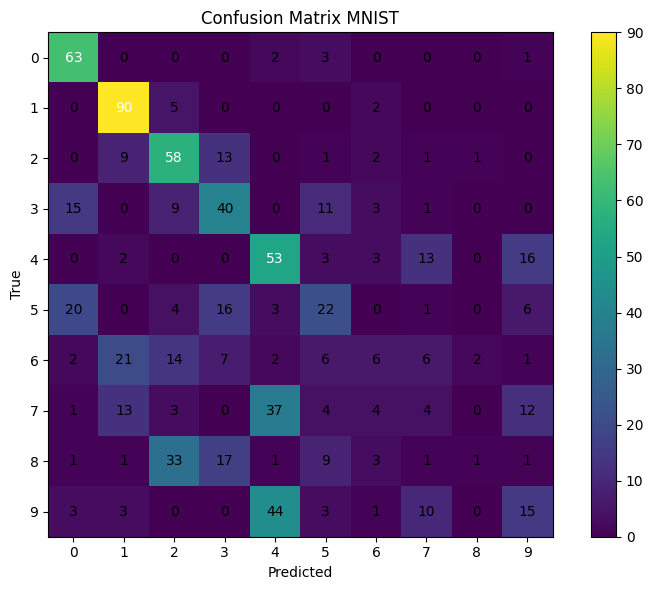

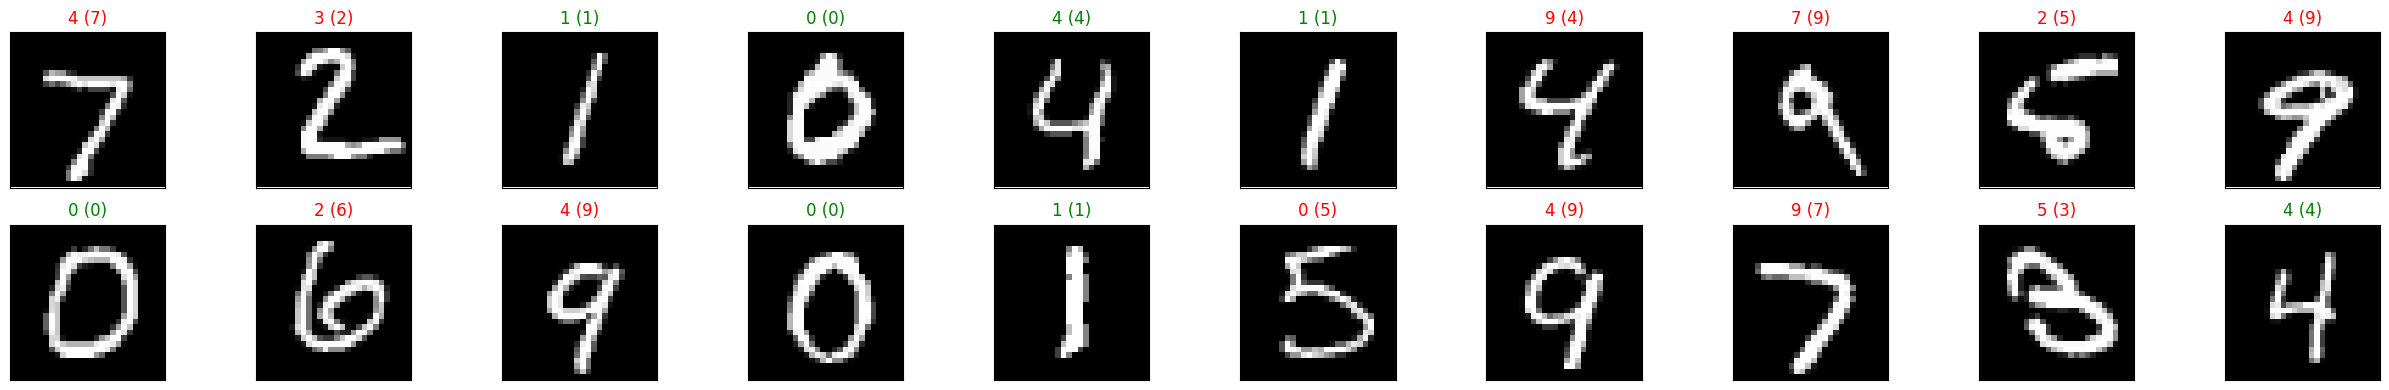

In [ ]:
# Data constants
input_size = 28 * 28
num_classes = 10
# Hyperparameters
batch_size = 128
lr = 0.1
num_epochs = 50
hidden_sizes = [2] # Use a list for hidden_sizes for consistency with init_model
selected_loss_type = 'sum_absolute' # Options: 'sum_absolute', 'mse', 'cross_entropy'

num_layers = len(hidden_sizes) + 1 # +1 for the output layer

# Initialize model parameters using the init_model function
params = init_model(input_size, hidden_sizes, num_classes)

# Call the train_model function with the correct signature
params, loss_train_history, loss_val_history = train_model(
    params,
    train_loader, val_loader, lr, num_epochs, num_classes,
    num_layers, loss_type=selected_loss_type
)

evaluate_model(
    params,
    test_loader, num_classes, num_layers, loss_type=selected_loss_type
)

Loss -> CE

Epoch:1 - Loss Train=2.2979 ; Loss Val=2.2936
Epoch:2 - Loss Train=2.2891 ; Loss Val=2.2841
Epoch:3 - Loss Train=2.2693 ; Loss Val=2.2643
Epoch:4 - Loss Train=2.2519 ; Loss Val=2.2371
Epoch:5 - Loss Train=2.2166 ; Loss Val=2.2015
Epoch:6 - Loss Train=2.1877 ; Loss Val=2.1684
Epoch:7 - Loss Train=2.1472 ; Loss Val=2.1330
Epoch:8 - Loss Train=2.1040 ; Loss Val=2.1005
Epoch:9 - Loss Train=2.0751 ; Loss Val=2.0700
Epoch:10 - Loss Train=2.0471 ; Loss Val=2.0415
Epoch:11 - Loss Train=1.9853 ; Loss Val=2.0066
Epoch:12 - Loss Train=1.9701 ; Loss Val=1.9780
Epoch:13 - Loss Train=1.9275 ; Loss Val=1.9422
Epoch:14 - Loss Train=1.8988 ; Loss Val=1.9094
Epoch:15 - Loss Train=1.8488 ; Loss Val=1.8818
Epoch:16 - Loss Train=1.8267 ; Loss Val=1.8574
Epoch:17 - Loss Train=1.7834 ; Loss Val=1.8295
Epoch:18 - Loss Train=1.7837 ; Loss Val=1.8118
Epoch:19 - Loss Train=1.7167 ; Loss Val=1.7903
Epoch:20 - Loss Train=1.6934 ; Loss Val=1.7733
Epoch:21 - Loss Train=1.7010 ; Loss Val=1.7592
Epoch:22 - Loss Train=

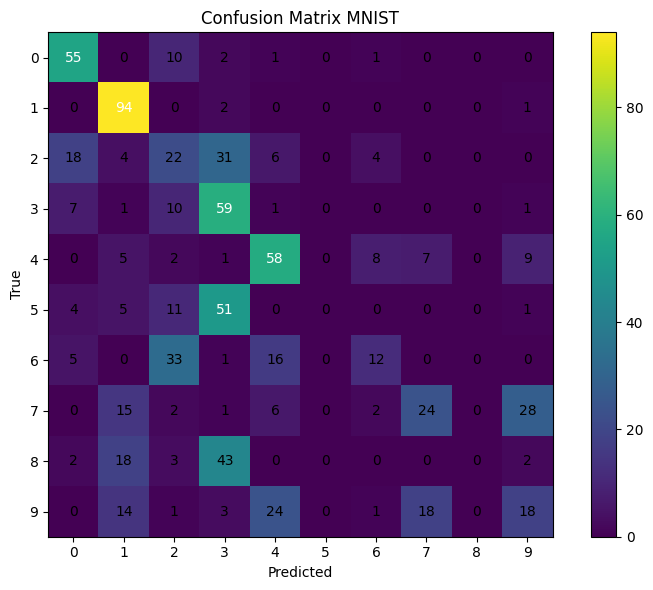

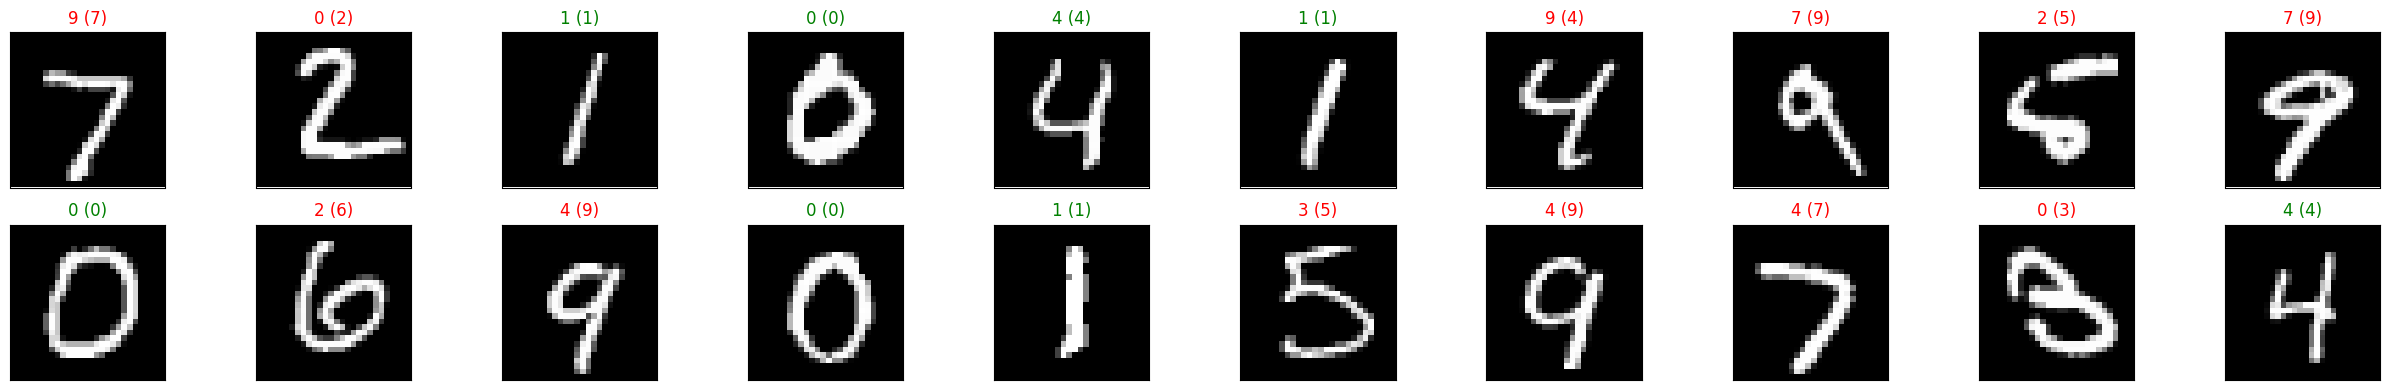

In [ ]:
# Data constants
input_size = 28 * 28
num_classes = 10
# Hyperparameters
batch_size = 128
lr = 0.1
num_epochs = 50
hidden_sizes = [2] # Use a list for hidden_sizes for consistency with init_model
selected_loss_type = 'cross_entropy' # Options: 'sum_absolute', 'mse', 'cross_entropy'

num_layers = len(hidden_sizes) + 1 # +1 for the output layer

# Initialize model parameters using the init_model function
params = init_model(input_size, hidden_sizes, num_classes)

# Call the train_model function with the correct signature
params, loss_train_history, loss_val_history = train_model(
    params,
    train_loader, val_loader, lr, num_epochs, num_classes,
    num_layers, loss_type=selected_loss_type
)

evaluate_model(
    params,
    test_loader, num_classes, num_layers, loss_type=selected_loss_type
)

- Loss -> CE
- hidden size -> 200

Epoch:1 - Loss Train=2.0553 ; Loss Val=2.0360
Epoch:2 - Loss Train=1.4288 ; Loss Val=1.4053
Epoch:3 - Loss Train=0.9940 ; Loss Val=1.1804
Epoch:4 - Loss Train=0.8040 ; Loss Val=1.0306
Epoch:5 - Loss Train=0.6762 ; Loss Val=0.9410
Epoch:6 - Loss Train=0.5926 ; Loss Val=0.8770
Epoch:7 - Loss Train=0.5359 ; Loss Val=0.8795
Epoch:8 - Loss Train=0.4873 ; Loss Val=0.7599
Epoch:9 - Loss Train=0.4364 ; Loss Val=0.7128
Epoch:10 - Loss Train=0.4132 ; Loss Val=0.8811
Epoch:11 - Loss Train=0.4367 ; Loss Val=0.7056
Epoch:12 - Loss Train=0.3722 ; Loss Val=0.6644
Epoch:13 - Loss Train=0.3405 ; Loss Val=0.6588
Epoch:14 - Loss Train=0.3420 ; Loss Val=0.6390
Epoch:15 - Loss Train=0.3098 ; Loss Val=0.6123
Epoch:16 - Loss Train=0.3403 ; Loss Val=0.6212
Epoch:17 - Loss Train=0.2835 ; Loss Val=0.5877
Epoch:18 - Loss Train=0.2660 ; Loss Val=0.5891
Epoch:19 - Loss Train=0.3089 ; Loss Val=0.6076
Epoch:20 - Loss Train=0.2314 ; Loss Val=0.5825
Epoch:21 - Loss Train=0.2385 ; Loss Val=0.5841
Epoch:22 - Loss Train=

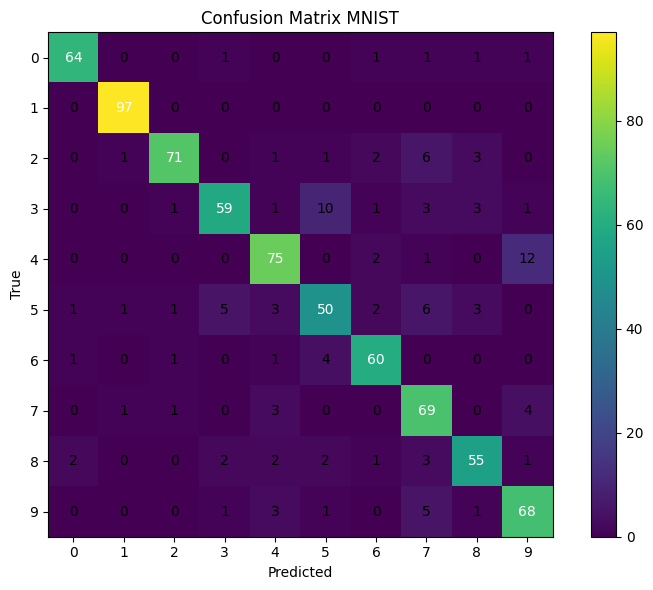

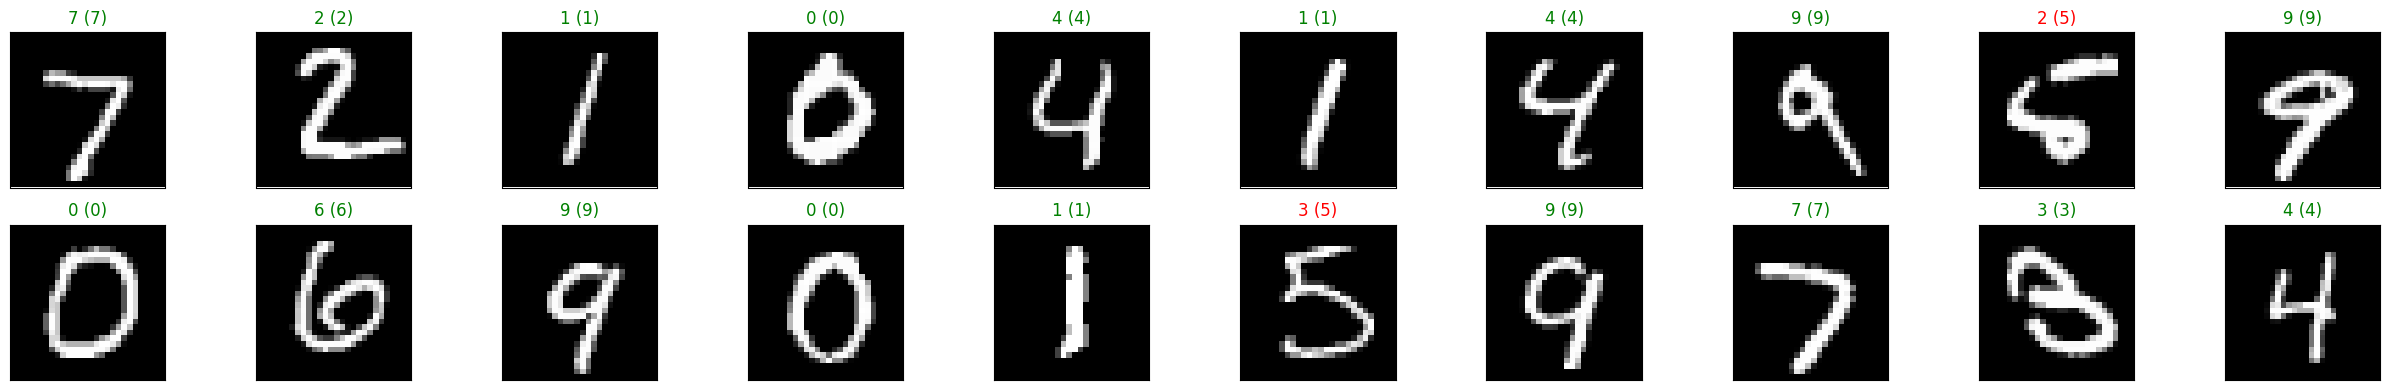

In [ ]:
# Data constants
input_size = 28 * 28
num_classes = 10
# Hyperparameters
batch_size = 128
lr = 0.1
num_epochs = 50
hidden_sizes = [200] # Use a list for hidden_sizes for consistency with init_model
selected_loss_type = 'cross_entropy' # Options: 'sum_absolute', 'mse', 'cross_entropy'

num_layers = len(hidden_sizes) + 1 # +1 for the output layer

# Initialize model parameters using the init_model function
params = init_model(input_size, hidden_sizes, num_classes)

# Call the train_model function with the correct signature
params, loss_train_history, loss_val_history = train_model(
    params,
    train_loader, val_loader, lr, num_epochs, num_classes,
    num_layers, loss_type=selected_loss_type
)

evaluate_model(
    params,
    test_loader, num_classes, num_layers, loss_type=selected_loss_type

    )

- Loss -> CE
- hidden size -> 200
- epoch -> 150


Epoch:1 - Loss Train=1.9156 ; Loss Val=1.5849
Epoch:2 - Loss Train=1.0582 ; Loss Val=1.2712
Epoch:3 - Loss Train=0.7333 ; Loss Val=0.9551
Epoch:4 - Loss Train=0.5890 ; Loss Val=0.8498
Epoch:5 - Loss Train=0.4907 ; Loss Val=0.7377
Epoch:6 - Loss Train=0.4366 ; Loss Val=0.7587
Epoch:7 - Loss Train=0.3822 ; Loss Val=0.7082
Epoch:8 - Loss Train=0.3329 ; Loss Val=0.6502
Epoch:9 - Loss Train=0.3170 ; Loss Val=0.6223
Epoch:10 - Loss Train=0.2708 ; Loss Val=0.6162
Epoch:11 - Loss Train=0.2541 ; Loss Val=0.6212
Epoch:12 - Loss Train=0.2379 ; Loss Val=0.6503
Epoch:13 - Loss Train=0.2155 ; Loss Val=0.5784
Epoch:14 - Loss Train=0.2004 ; Loss Val=0.5712
Epoch:15 - Loss Train=0.1857 ; Loss Val=0.5693
Epoch:16 - Loss Train=0.1783 ; Loss Val=0.5808
Epoch:17 - Loss Train=0.1595 ; Loss Val=0.5445
Epoch:18 - Loss Train=0.1615 ; Loss Val=0.5646
Epoch:19 - Loss Train=0.1445 ; Loss Val=0.5376
Epoch:20 - Loss Train=0.1284 ; Loss Val=0.5409
Epoch:21 - Loss Train=0.1185 ; Loss Val=0.5346
Epoch:22 - Loss Train=

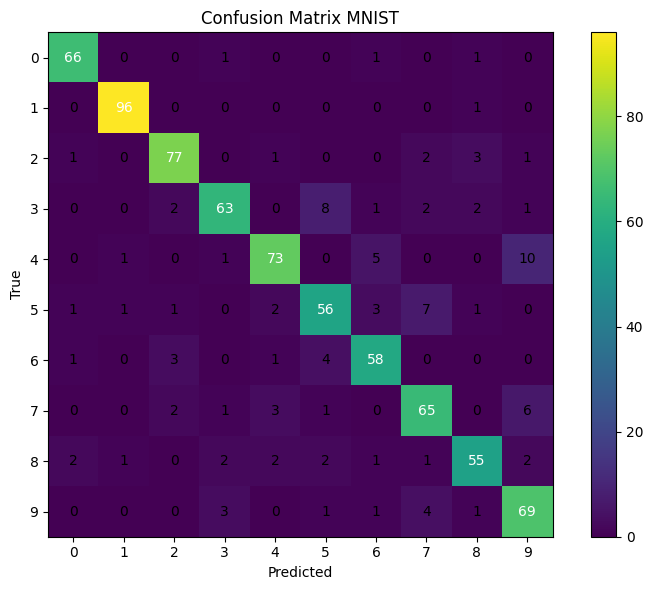

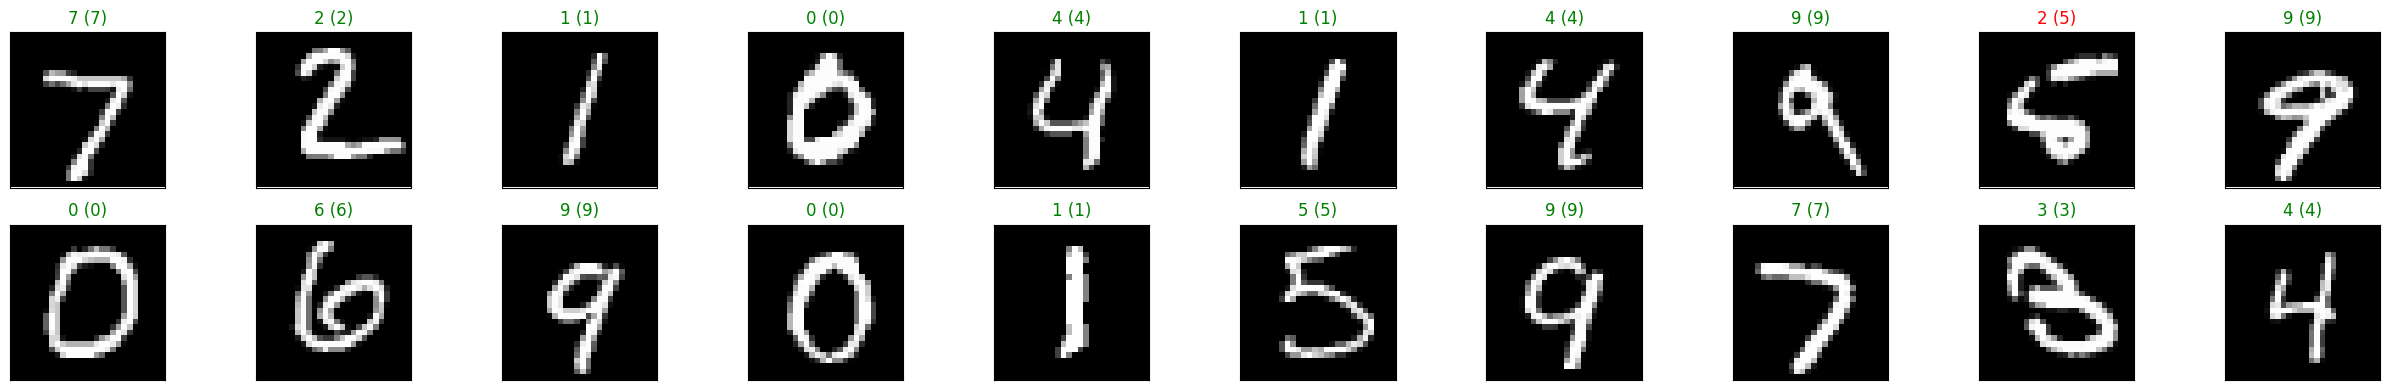

In [ ]:
# Data constants
input_size = 28 * 28
num_classes = 10
# Hyperparameters
batch_size = 64
lr = 0.1
num_epochs = 150
hidden_sizes = [200]
selected_loss_type = 'cross_entropy' # Options: 'sum_absolute', 'mse', 'cross_entropy'

num_layers = len(hidden_sizes) + 1 # +1 for the output layer

# Initialize model parameters
params = init_model(input_size, hidden_sizes, num_classes)

# Call the new train_model function
params, loss_train_history, loss_val_history = train_model(
    params,
    train_loader, val_loader, lr, num_epochs, num_classes,
    num_layers, loss_type=selected_loss_type
)

evaluate_model(
    params,
    test_loader, num_classes, num_layers, loss_type=selected_loss_type
)

- Loss -> CE
- hidden size -> 200
- epoch -> 150
- batch size -> 128

Epoch:1 - Loss Train=2.0601 ; Loss Val=1.7842
Epoch:2 - Loss Train=1.4093 ; Loss Val=1.3289
Epoch:3 - Loss Train=1.0185 ; Loss Val=1.1084
Epoch:4 - Loss Train=0.8177 ; Loss Val=1.1014
Epoch:5 - Loss Train=0.6738 ; Loss Val=0.8856
Epoch:6 - Loss Train=0.6161 ; Loss Val=0.8202
Epoch:7 - Loss Train=0.5512 ; Loss Val=0.8202
Epoch:8 - Loss Train=0.5232 ; Loss Val=0.7915
Epoch:9 - Loss Train=0.4825 ; Loss Val=0.7701
Epoch:10 - Loss Train=0.4406 ; Loss Val=0.7579
Epoch:11 - Loss Train=0.4046 ; Loss Val=0.7161
Epoch:12 - Loss Train=0.3596 ; Loss Val=0.6283
Epoch:13 - Loss Train=0.3495 ; Loss Val=0.6322
Epoch:14 - Loss Train=0.3169 ; Loss Val=0.5956
Epoch:15 - Loss Train=0.3453 ; Loss Val=0.6827
Epoch:16 - Loss Train=0.2941 ; Loss Val=0.5834
Epoch:17 - Loss Train=0.2921 ; Loss Val=0.5951
Epoch:18 - Loss Train=0.2653 ; Loss Val=0.6249
Epoch:19 - Loss Train=0.2527 ; Loss Val=0.5796
Epoch:20 - Loss Train=0.2568 ; Loss Val=0.5768
Epoch:21 - Loss Train=0.2467 ; Loss Val=0.7116
Epoch:22 - Loss Train=

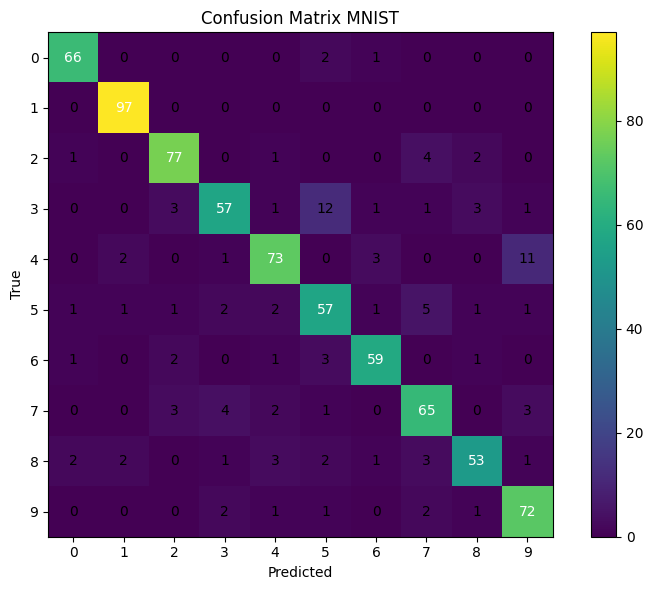

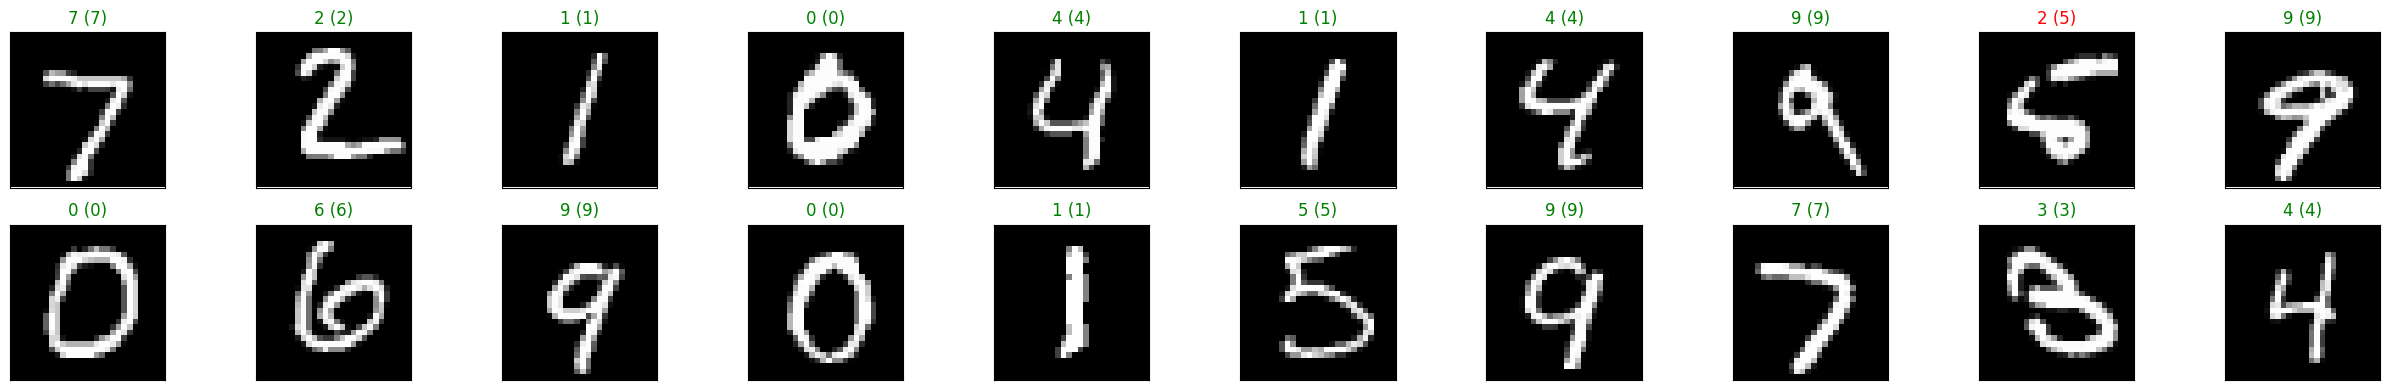

In [ ]:
# Data constants
input_size = 28 * 28
num_classes = 10
# Hyperparameters
batch_size = 128
lr = 0.1
num_epochs = 150
hidden_sizes = [200]
selected_loss_type = 'cross_entropy' # Options: 'sum_absolute', 'mse', 'cross_entropy'

num_layers = len(hidden_sizes) + 1 # +1 for the output layer

# Initialize model parameters
params = init_model(input_size, hidden_sizes, num_classes)

# Call the new train_model function
params, loss_train_history, loss_val_history = train_model(
    params,
    train_loader, val_loader, lr, num_epochs, num_classes,
    num_layers, loss_type=selected_loss_type
)

evaluate_model(
    params,
    test_loader, num_classes, num_layers, loss_type=selected_loss_type
)

- Loss -> CE
- hidden size -> 200
- epoch -> 150
- batch size -> 128
- Lr -> 0.02

Epoch:1 - Loss Train=2.3510 ; Loss Val=2.2365
Epoch:2 - Loss Train=1.9761 ; Loss Val=1.9788
Epoch:3 - Loss Train=1.7335 ; Loss Val=1.7866
Epoch:4 - Loss Train=1.5191 ; Loss Val=1.6369
Epoch:5 - Loss Train=1.3511 ; Loss Val=1.5027
Epoch:6 - Loss Train=1.2252 ; Loss Val=1.3925
Epoch:7 - Loss Train=1.0955 ; Loss Val=1.3086
Epoch:8 - Loss Train=1.0074 ; Loss Val=1.2319
Epoch:9 - Loss Train=0.9376 ; Loss Val=1.1706
Epoch:10 - Loss Train=0.8487 ; Loss Val=1.1138
Epoch:11 - Loss Train=0.8027 ; Loss Val=1.0692
Epoch:12 - Loss Train=0.7607 ; Loss Val=1.0280
Epoch:13 - Loss Train=0.7017 ; Loss Val=0.9933
Epoch:14 - Loss Train=0.6717 ; Loss Val=0.9630
Epoch:15 - Loss Train=0.6361 ; Loss Val=0.9336
Epoch:16 - Loss Train=0.6245 ; Loss Val=0.9141
Epoch:17 - Loss Train=0.5996 ; Loss Val=0.8924
Epoch:18 - Loss Train=0.5681 ; Loss Val=0.8644
Epoch:19 - Loss Train=0.5490 ; Loss Val=0.8493
Epoch:20 - Loss Train=0.5452 ; Loss Val=0.8331
Epoch:21 - Loss Train=0.4963 ; Loss Val=0.8169
Epoch:22 - Loss Train=

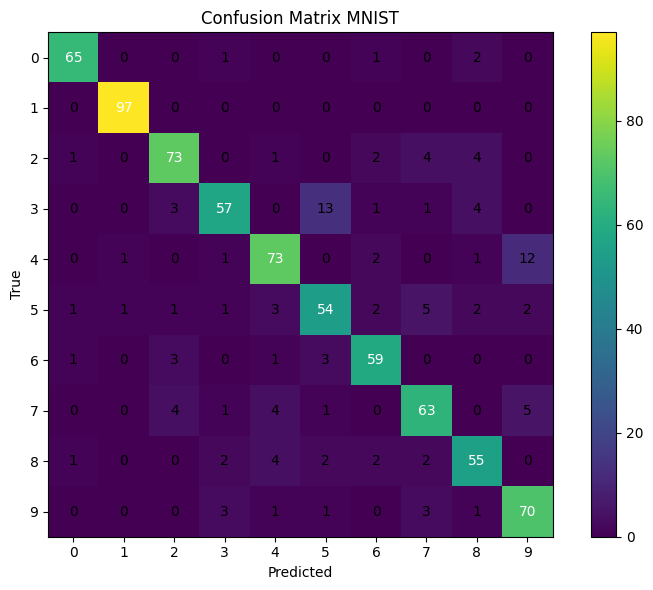

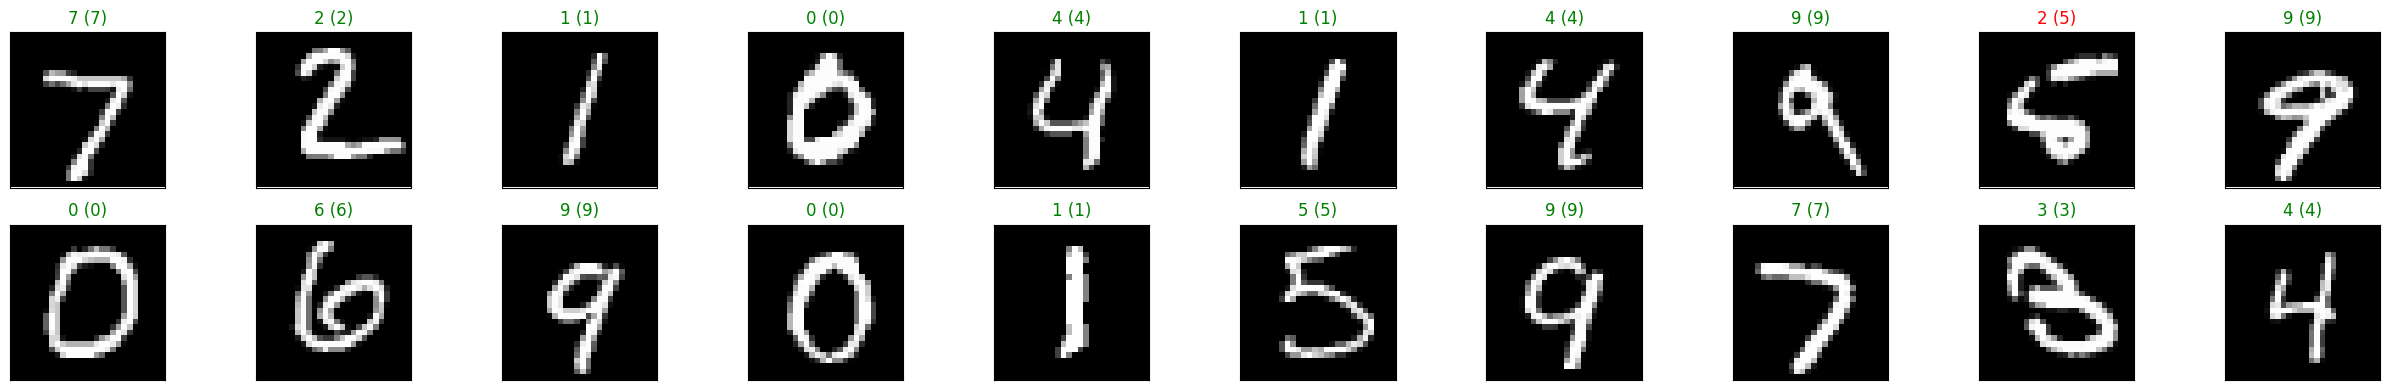

In [ ]:
# Data constants
input_size = 28 * 28
num_classes = 10
# Hyperparameters
batch_size = 64
lr = 0.02
num_epochs = 150
hidden_sizes = [200] # Use a list for hidden_sizes for consistency with init_model
selected_loss_type = 'cross_entropy' # Options: 'sum_absolute', 'mse', 'cross_entropy'

num_layers = len(hidden_sizes) + 1 # +1 for the output layer

# Initialize model parameters using the init_model function
params = init_model(input_size, hidden_sizes, num_classes)

# Call the train_model function with the correct signature
params, loss_train_history, loss_val_history = train_model(
    params,
    train_loader, val_loader, lr, num_epochs, num_classes,
    num_layers, loss_type=selected_loss_type
)

evaluate_model(
    params,
    test_loader, num_classes, num_layers, loss_type=selected_loss_type
)

- Loss -> CE
- hidden size -> 512
- epoch -> 150
- batch size -> 128
- Lr -> 0.02

Epoch:1 - Loss Train=2.7460 ; Loss Val=2.3782
Epoch:2 - Loss Train=2.0454 ; Loss Val=2.0069
Epoch:3 - Loss Train=1.6965 ; Loss Val=1.7555
Epoch:4 - Loss Train=1.3789 ; Loss Val=1.5244
Epoch:5 - Loss Train=1.1747 ; Loss Val=1.4061
Epoch:6 - Loss Train=1.0383 ; Loss Val=1.2962
Epoch:7 - Loss Train=0.9823 ; Loss Val=1.2087
Epoch:8 - Loss Train=0.8745 ; Loss Val=1.1415
Epoch:9 - Loss Train=0.7789 ; Loss Val=1.1006
Epoch:10 - Loss Train=0.7136 ; Loss Val=1.0459
Epoch:11 - Loss Train=0.7040 ; Loss Val=0.9926
Epoch:12 - Loss Train=0.7044 ; Loss Val=0.9713
Epoch:13 - Loss Train=0.6016 ; Loss Val=0.9320
Epoch:14 - Loss Train=0.5958 ; Loss Val=0.9254
Epoch:15 - Loss Train=0.5528 ; Loss Val=0.8815
Epoch:16 - Loss Train=0.5752 ; Loss Val=0.8677
Epoch:17 - Loss Train=0.5253 ; Loss Val=0.8432
Epoch:18 - Loss Train=0.5048 ; Loss Val=0.8423
Epoch:19 - Loss Train=0.4744 ; Loss Val=0.8150
Epoch:20 - Loss Train=0.4946 ; Loss Val=0.8134
Epoch:21 - Loss Train=0.4682 ; Loss Val=0.8115
Epoch:22 - Loss Train=

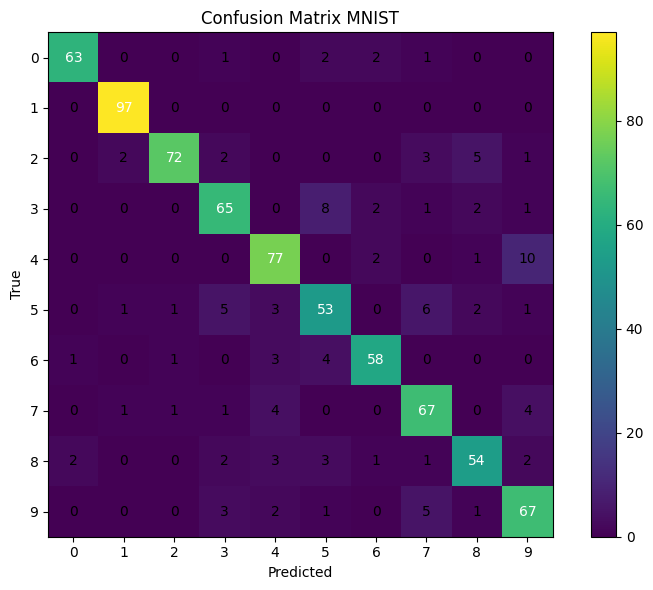

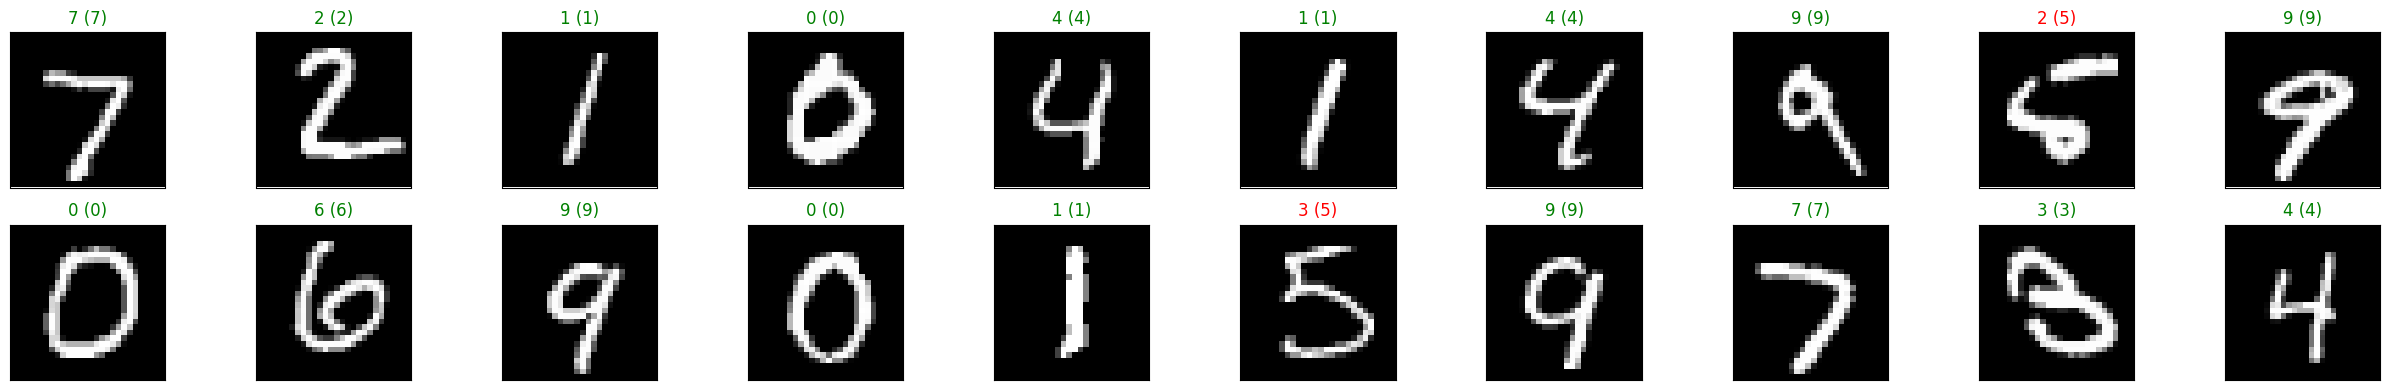

In [ ]:
# Data constants
input_size = 28 * 28
num_classes = 10
# Hyperparameters
batch_size = 128
lr = 0.02
num_epochs = 150
hidden_sizes = [512] # Use a list for hidden_sizes for consistency with init_model
selected_loss_type = 'cross_entropy' # Options: 'sum_absolute', 'mse', 'cross_entropy'

num_layers = len(hidden_sizes) + 1 # +1 for the output layer

# Initialize model parameters using the init_model function
params = init_model(input_size, hidden_sizes, num_classes)

# Call the train_model function with the correct signature
params, loss_train_history, loss_val_history = train_model(
    params,
    train_loader, val_loader, lr, num_epochs, num_classes,
    num_layers, loss_type=selected_loss_type
)

evaluate_model(
    params,
    test_loader, num_classes, num_layers, loss_type=selected_loss_type
)

- Loss -> CE
- hidden size -> [512, 256, 128, 64]
- epoch -> 150
- batch size -> 128
- Lr -> 0.02

Epoch:1 - Loss Train=2.2432 ; Loss Val=2.1460
Epoch:2 - Loss Train=2.0008 ; Loss Val=1.9988
Epoch:3 - Loss Train=1.8047 ; Loss Val=1.8533
Epoch:4 - Loss Train=1.6038 ; Loss Val=1.6922
Epoch:5 - Loss Train=1.4234 ; Loss Val=1.5313
Epoch:6 - Loss Train=1.2360 ; Loss Val=1.4165
Epoch:7 - Loss Train=1.1040 ; Loss Val=1.2678
Epoch:8 - Loss Train=0.9738 ; Loss Val=1.1676
Epoch:9 - Loss Train=0.8293 ; Loss Val=1.1131
Epoch:10 - Loss Train=0.7618 ; Loss Val=1.1230
Epoch:11 - Loss Train=0.6969 ; Loss Val=0.9840
Epoch:12 - Loss Train=0.6048 ; Loss Val=0.9566
Epoch:13 - Loss Train=0.5924 ; Loss Val=0.8877
Epoch:14 - Loss Train=0.5167 ; Loss Val=0.8857
Epoch:15 - Loss Train=0.4913 ; Loss Val=0.8068
Epoch:16 - Loss Train=0.4825 ; Loss Val=0.8706
Epoch:17 - Loss Train=0.4434 ; Loss Val=0.7944
Epoch:18 - Loss Train=0.4027 ; Loss Val=0.7895
Epoch:19 - Loss Train=0.3780 ; Loss Val=0.7930
Epoch:20 - Loss Train=0.3673 ; Loss Val=0.7832
Epoch:21 - Loss Train=0.3380 ; Loss Val=0.7605
Epoch:22 - Loss Train=

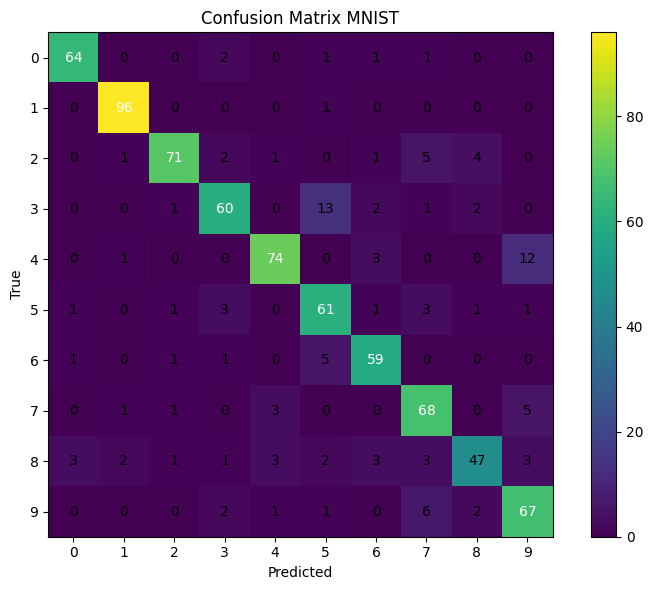

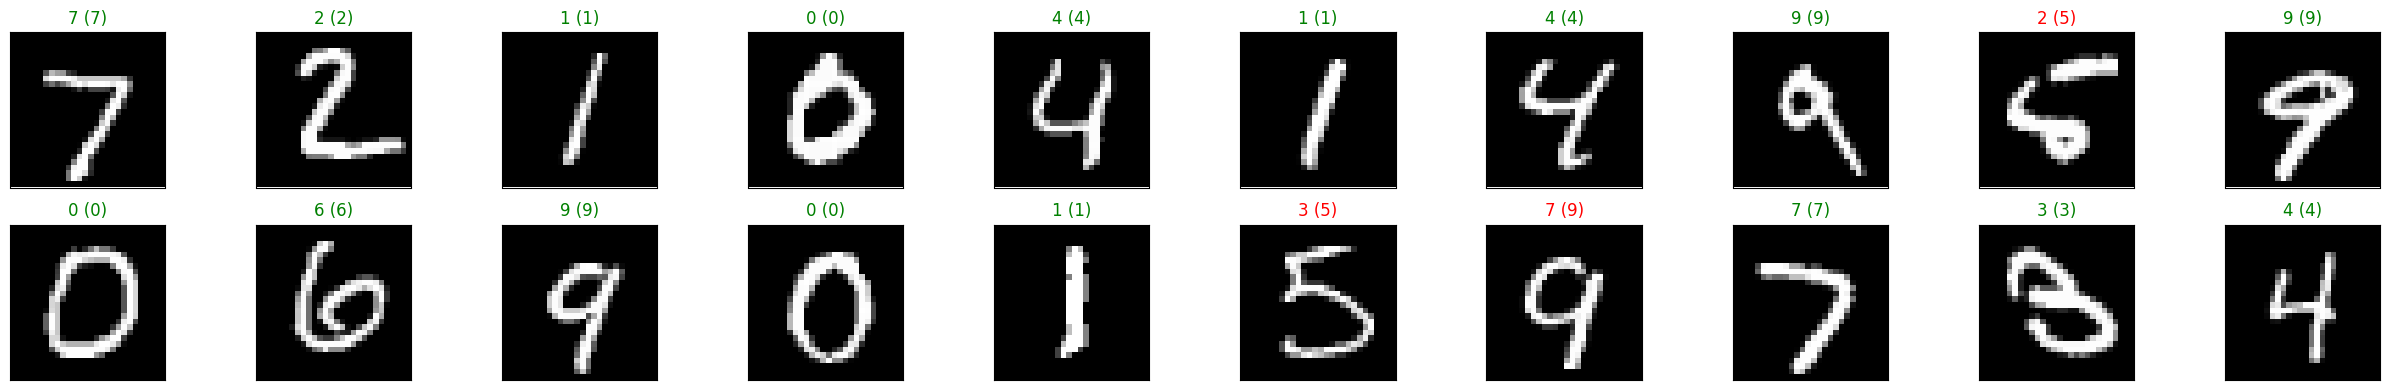

In [ ]:
# Data constants
input_size = 28 * 28
num_classes = 10
# Hyperparameters
batch_size = 128
lr = 0.02
num_epochs = 150
hidden_sizes = [512, 256, 128, 64] # Use a list for hidden_sizes for consistency with init_model
selected_loss_type = 'cross_entropy' # Options: 'sum_absolute', 'mse', 'cross_entropy'

num_layers = len(hidden_sizes) + 1 # +1 for the output layer

# Initialize model parameters using the init_model function
params = init_model(input_size, hidden_sizes, num_classes)

# Call the train_model function with the correct signature
params, loss_train_history, loss_val_history = train_model(
    params,
    train_loader, val_loader, lr, num_epochs, num_classes,
    num_layers, loss_type=selected_loss_type
)

evaluate_model(
    params,
    test_loader, num_classes, num_layers, loss_type=selected_loss_type
)

## 3.1 Implementasi Model dengan TensorFlow dan Adam Optimization

Pada percobaan kali ini digunakan framework TensorFlow, untuk mempermudah training. Selain itu sebelum dilakukan proses inferensi dilakukan perhitungan dengan filter konvolusi sehingga output memiliki feature yang lebih baik.

1. Proses awal dilakukan dengan melakukan konvolusi dengan filter random yang memiliki kernel 3x3. Fitering dibuat 32 kali untuk mengekstrak fitur yang berbeda dari gambar. jumlah param =  (jumlah kernel + bias) x fitur = (3x3+1) x 32 = 320

2. Selanjutnya dilakukan maxpooling 2x2 dengan stride 2 untuk melakukan agregasi dari fitur yang diekstrak filter konvolusi.

3.  Selanjutnya dilakukan batch normalization untuk mempercepat waktu training. Hal ini karena Batch normalization membuat step pada fungsi kontur menjadi lebih homogen. Sehingga jika step dipadukan dengan learning rate, maka jumlah step tiap fungsi akan cenderung sama. Agar fungsi tidak menghasilkan perubahan yang sama terus ditambahkan parameter gamma dan beta. Gamma dan beta tersebut akan ditrain bersamaan dengan model. karena dilakukan scaling fungsi per fitur, terdapat 4 parameter setiap filter yaitu gamma, beta, moving mean, dan moving std.

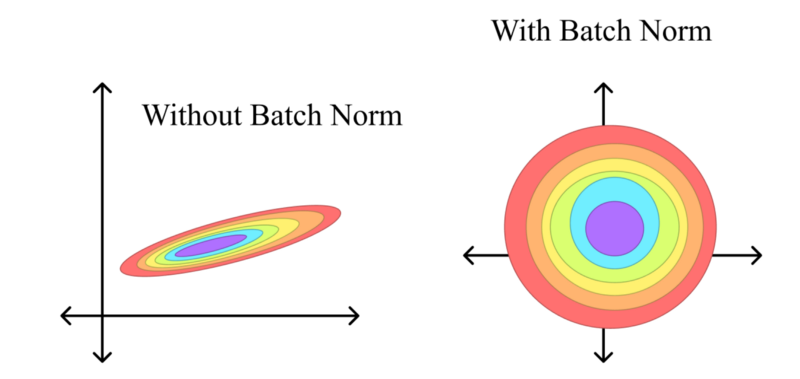

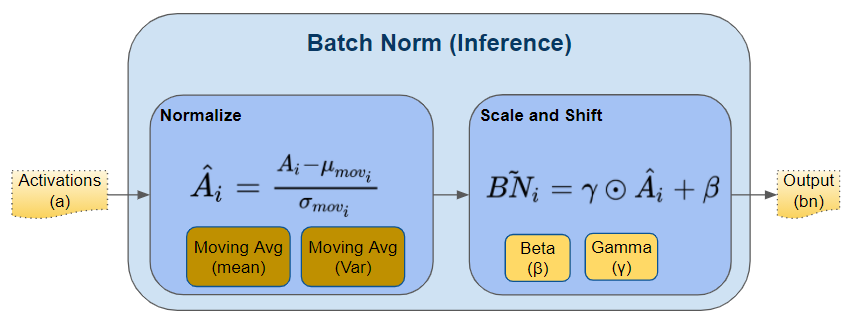

4. Proses selanjutnya adalah konvolusi ulang dengan kernel 3x3 dan karena output adalah 26x26x32, jumlah parameter baru adalah (26x26x32+1) x 64.

5. Dilakukan max pooling lagi.

6. Dilakukan training dengan adam optimizer. Dengan adanya adam optimizer terdapat momentum awal sehingga gradien tidak terjebak pada local minimum. Selanjutnya learning rate berubah sesuai dengan parameter yang diupdate, hal ini dilakukan agar jumlah step pada setiap parameter lebih seragam.

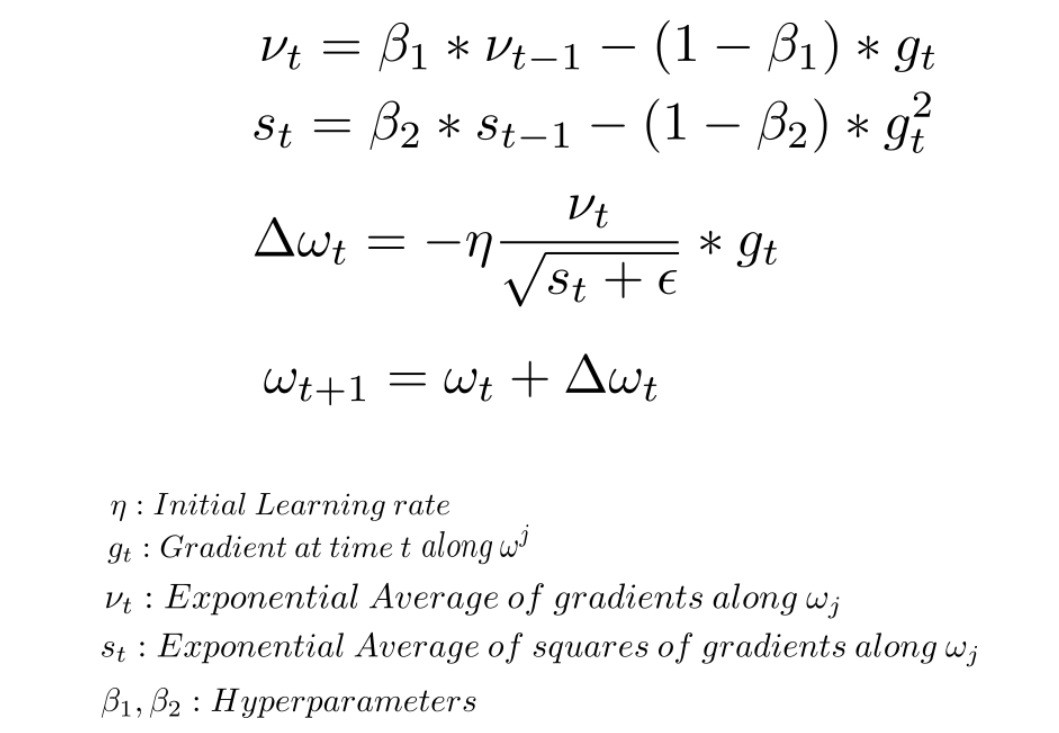


### 3.2 Implementasi Model CNN dengan Batch Normalization dan MaxPooling


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
import numpy as np
import matplotlib.pyplot as plt

# Data constants from previous cells
input_size = 28 * 28
num_classes = 10

# Hyperparameters (using the same as the last successful run for comparison)
batch_size = 64
lr = 0.02
num_epochs = 150
hidden_sizes = [512, 256, 128, 64] # For the Dense layers after Flatten

# Ensure data is in float32 format for TensorFlow and reshape X for CNN
X_train_tf_cnn = X_train_val[:50000].astype('float32').reshape(-1, 28, 28, 1)
y_train_tf_cnn = y_train_val[:50000].astype('int8')
X_val_tf_cnn = X_train_val[50000:].astype('float32').reshape(-1, 28, 28, 1)
y_val_tf_cnn = y_train_val[50000:].astype('int8')
X_test_tf_cnn = X_test.astype('float32').reshape(-1, 28, 28, 1)
y_test_tf_cnn = y_test.astype('int8')


# Define the CNN Model Architecture
cnn_model = Sequential()

# Convolutional Block 1
cnn_model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2, 2)))

# Convolutional Block 2 (optional, but common for deeper networks)
cnn_model.add(Conv2D(64, (3, 3), activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2, 2)))

# Flatten the output for the Dense layers
cnn_model.add(Flatten())

# Dense layers (using the hidden_sizes defined earlier)
for h_size in hidden_sizes:
    cnn_model.add(Dense(h_size, activation='relu'))
    cnn_model.add(BatchNormalization()) # Adding batch normalization to dense layers as well

# Output layer
cnn_model.add(Dense(num_classes, activation='softmax'))

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       819,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,015,882 (3.88 MB)

 Trainable params: 1,013,770 (3.87 MB)

 Non-trainable params: 2,112 (8.25 KB)

### 3.3 Compile CNN Model dengan Adam Optimizer

In [ ]:
# Compile the CNN Model
optimizer_cnn = Adam(learning_rate=lr)
loss_fn_cnn = SparseCategoricalCrossentropy()

cnn_model.compile(optimizer=optimizer_cnn, loss=loss_fn_cnn, metrics=['accuracy'])

### 3.4 Train CNN Model

In [ ]:
# Train the CNN Model
history_cnn = cnn_model.fit(
    X_train_tf_cnn, y_train_tf_cnn,
    batch_size=batch_size,
    epochs=num_epochs,
    validation_data=(X_val_tf_cnn, y_val_tf_cnn),
    verbose=1
)

Epoch 1/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9524 - loss: 0.1675 - val_accuracy: 0.9750 - val_loss: 0.0992
Epoch 2/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9762 - loss: 0.0833 - val_accuracy: 0.9162 - val_loss: 0.2712
Epoch 3/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9805 - loss: 0.0707 - val_accuracy: 0.9698 - val_loss: 0.1215
Epoch 4/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9850 - loss: 0.0548 - val_accuracy: 0.9845 - val_loss: 0.0612
Epoch 5/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9863 - loss: 0.0488 - val_accuracy: 0.9815 - val_loss: 0.0684
Epoch 6/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9884 - loss: 0.0413 - val_accuracy: 0.9852 - val_loss: 0.0564
Epoch 7/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9902 - loss: 0.0347 - val_accuracy: 0.9878 - val_loss: 0.0492
Epoch 8/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9907 - loss: 0.0335 - val_ac

### 3.5 Evaluate CNN Model


Kualitas Model CNN TensorFlow terhadap Testing Data:
Acc = 0.9932
Loss = 0.0595


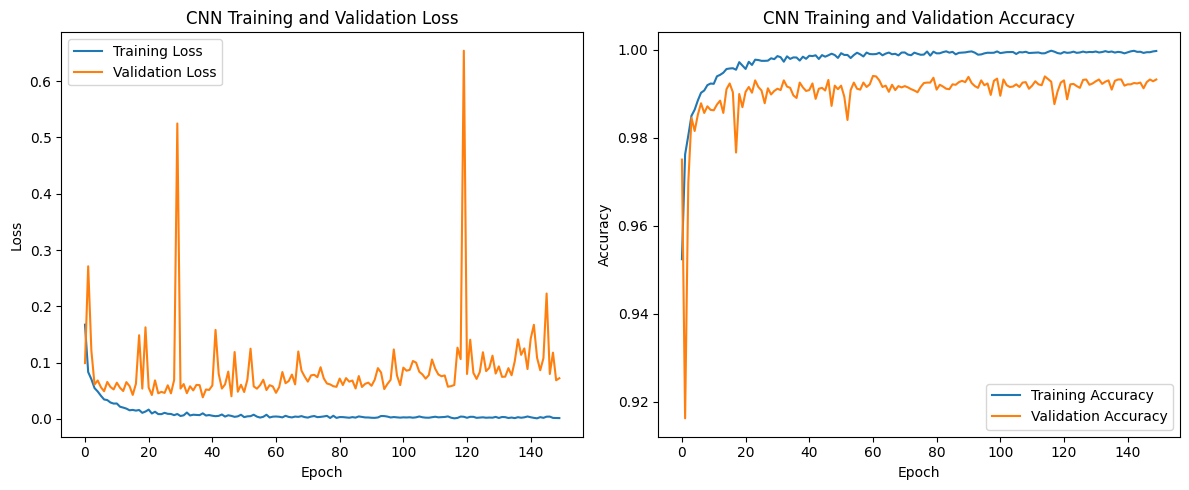

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [ ]:
# Evaluate the CNN Model
loss_cnn, accuracy_cnn = cnn_model.evaluate(X_test_tf_cnn, y_test_tf_cnn, verbose=0)
print(f"\nKualitas Model CNN TensorFlow terhadap Testing Data:")
print(f"Acc = {accuracy_cnn:.4f}")
print(f"Loss = {loss_cnn:.4f}")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions for the test set
y_pred_cnn = cnn_model.predict(X_test_tf_cnn)
y_pred_classes_cnn = np.argmax(y_pred_cnn, axis=1)




Confusion Matrix (TensorFlow CNN):
[[ 977    1    0    0    0    1    0    1    0    0]
 [   0 1131    1    1    0    0    1    0    0    1]
 [   0    2 1027    0    0    0    0    3    0    0]
 [   0    0    1 1002    0    3    0    2    1    1]
 [   0    0    0    0  975    0    4    0    1    2]
 [   0    1    1    6    0  880    2    1    0    1]
 [   3    2    0    0    0    0  952    0    1    0]
 [   0    1    2    0    0    0    0 1024    0    1]
 [   1    0    1    1    1    0    1    3  966    0]
 [   0    0    0    0    7    2    0    1    1  998]]


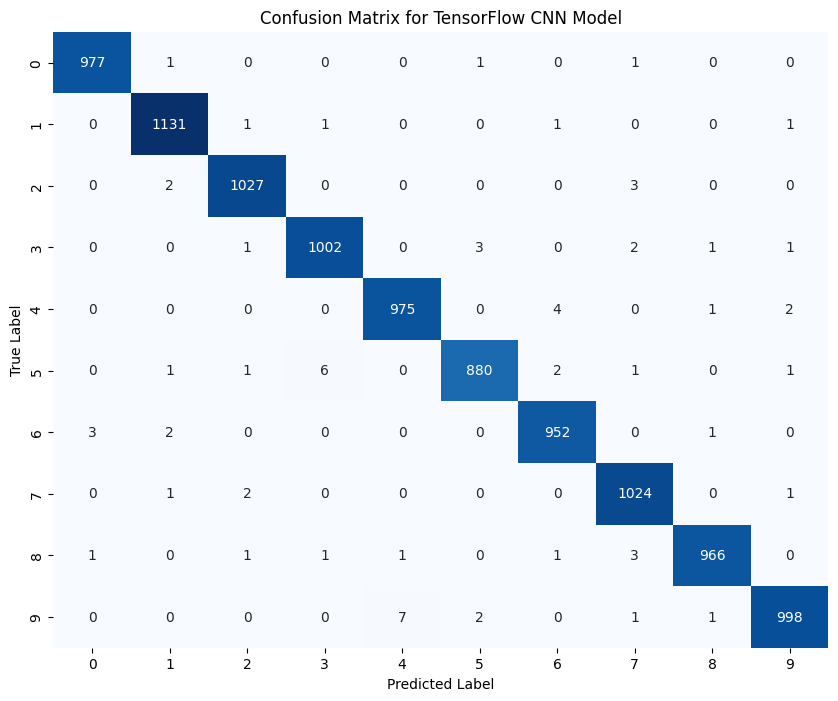

In [ ]:
# Generate confusion matrix
cm_cnn = confusion_matrix(y_test_tf_cnn, y_pred_classes_cnn)

print("\nConfusion Matrix (TensorFlow CNN):")
print(cm_cnn)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix for TensorFlow CNN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()